# AI/ML Bootcamp Lecture 3 - Part 1
Regression and Classification


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
height = 5
plt.rcParams["figure.figsize"] = [1.618*height, height]

## Regression - Simple Curve Fit

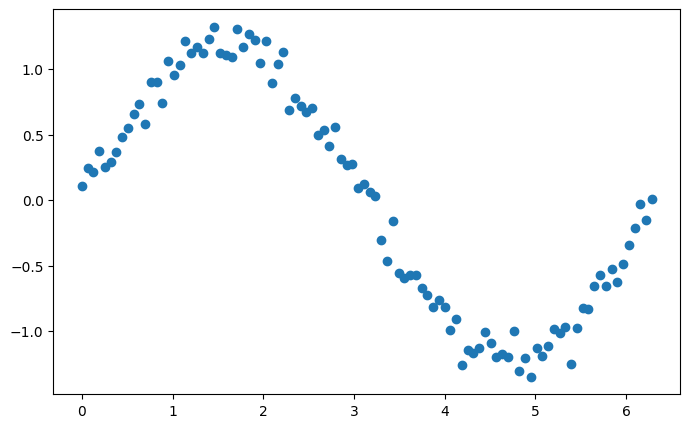

In [ ]:
x = np.linspace(0, np.pi*2, 100)
y = 1.2*np.sin(x) + 0.1*np.random.randn(100)
plt.plot(x, y, "o")
plt.show()

In [ ]:
def func(x, a, b):
  return a*np.sin(x) + b

In [ ]:
from scipy.optimize import curve_fit

fit_soln = curve_fit(func, x, y)
popt, pcov = fit_soln # curve fit returns a tuple

In [ ]:
# Print
print(f"a = {popt[0]:.3f} ± {np.sqrt(pcov[0][0]):.3f}")
print(f"b = {popt[1]:.3f} ± {np.sqrt(pcov[1][1]):.3f}")

a = 1.207 ± 0.015
b = -0.006 ± 0.010


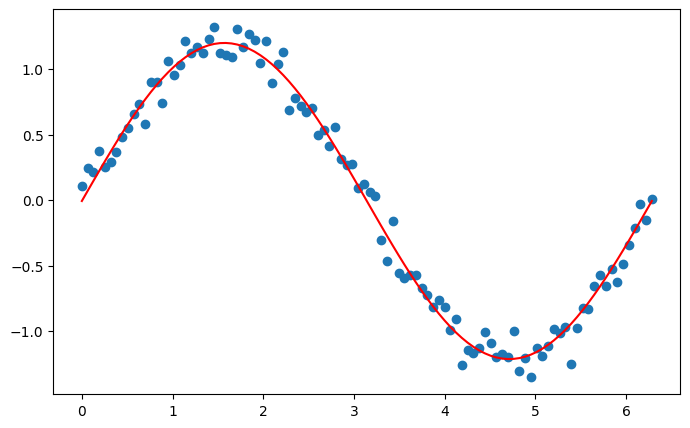

In [ ]:
plt.plot(x, y, 'o')
# plt.plot(x, func(x, popt[0], popt[1]), 'r-');
plt.plot(x, func(x, *popt), 'r-');

In [ ]:
# Calculate and print chi^2/ndf
y_fit = func(x, *popt)
chi_sq = np.sum((y - y_fit)**2)
ndf = len(x) - len(popt)
print(f"chi^2/ndf = {chi_sq/ndf:.3f}")

chi^2/ndf = 0.010


## Classificiation - Iris Classifier
For this in-class exercise we will look at the Iris dataset and use scikit learn to classify the different types of Irises.

## Individual Exercises (Optional Homework)
In addition to the Iris dataset you should also select 3 different datasets of your choosing and use the kNN classifier to build a model for them. You should show the accuracy of your model. Here is an excellent database to choose from:
- https://archive-beta.ics.uci.edu (Beta version)
- https://archive.ics.uci.edu/ml/datasets.php

### Requirements:
- You should show the accuracy of your model
- For each dataset you should give a short description of:
    - Why you chose the dataset
    - Any problems you encountered while building a classifier for it
- You should use markdown appropriately for annotating your code and answering the questions above
- Your jupyter notebook should function after running "Restart kernel and run all"

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
col_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'type']
df = pd.read_csv(url, names=col_names)

In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,type
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
# Split into 3 dataframes
df_setosa = df[df['type'] == 'Iris-setosa']
df_versicolor = df[df['type'] == 'Iris-versicolor']
df_virginica = df[df['type'] == 'Iris-virginica']

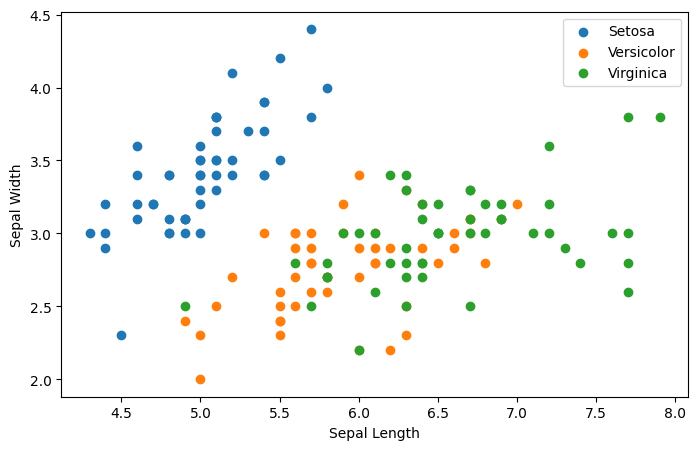

In [ ]:
# Plot Sepal Length vs Sepal Width
plt.scatter(df_setosa['sepal_length'], df_setosa['sepal_width'], label='Setosa')
plt.scatter(df_versicolor['sepal_length'], df_versicolor['sepal_width'], label='Versicolor')
plt.scatter(df_virginica['sepal_length'], df_virginica['sepal_width'], label='Virginica')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.show()

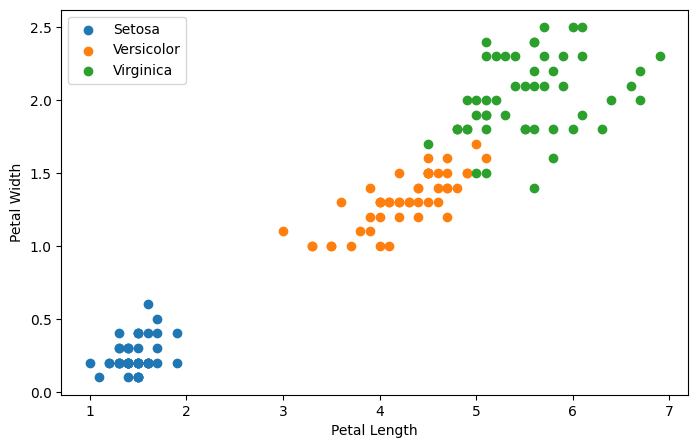

In [ ]:
# Plot petal length vs petal width
plt.scatter(df_setosa['petal_length'], df_setosa['petal_width'], label='Setosa')
plt.scatter(df_versicolor['petal_length'], df_versicolor['petal_width'], label='Versicolor')
plt.scatter(df_virginica['petal_length'], df_virginica['petal_width'], label='Virginica')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.legend()
plt.show();

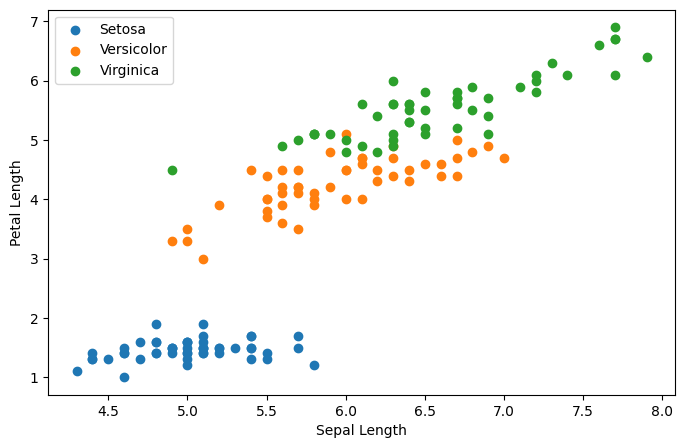

In [ ]:
# Sepal length vs petal length
plt.scatter(df_setosa['sepal_length'], df_setosa['petal_length'], label='Setosa')
plt.scatter(df_versicolor['sepal_length'], df_versicolor['petal_length'], label='Versicolor')
plt.scatter(df_virginica['sepal_length'], df_virginica['petal_length'], label='Virginica')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.legend()
plt.show();

In [ ]:
# Convert type from string to int
species = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
df['type'] = df['type'].map(species)

In [ ]:
data = df.drop('type', axis=1) # Remove the label
labels = df['type'];

In [ ]:
df

,sepal_length,sepal_width,petal_length,petal_width,type
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(data,
                                                                    labels,
                                                                    test_size=0.2,
                                                                    random_state=27)

In [ ]:
# Import kNN Classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(train_data, train_labels)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
knn.score(data, labels)

0.96

In [ ]:
scores = []
n_neighbors = []
for n in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(train_data, train_labels)
    scores.append(knn.score(test_data, test_labels))
    n_neighbors.append(n)

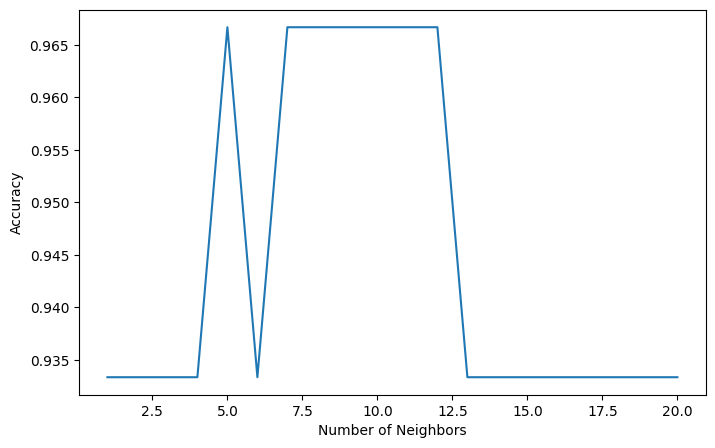

In [ ]:
# Plot the score
plt.plot(n_neighbors, scores)
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy')
plt.show()